In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Data Scraping using SP2KP API


In [ ]:
df = pd.read_json("https://api-sp2kp.kemendag.go.id/report/api/hnt/history-series?tanggal_start=2023-01-23&tanggal_end=2026-04-22&variant_id=2")

In [ ]:
df = df['data']

In [ ]:
df = pd.DataFrame(df.tolist())
df['tanggal_data'] = pd.to_datetime(df['tanggal_data'])
df.head()

,tanggal_data,harga
0,2024-02-01,52916
1,2024-02-02,53538
2,2024-02-03,53222
3,2024-02-04,50000
4,2024-02-05,56797


In [ ]:
df.tail()

,tanggal_data,harga
549,2026-04-16,36083
550,2026-04-17,36567
551,2026-04-20,39054
552,2026-04-21,39487
553,2026-04-22,40377


In [ ]:
df.to_csv('hnt_cabai_merah_keriting.csv', index=False)

# Import Data


In [32]:
df = pd.read_csv('https://raw.githubusercontent.com/Dekhsa/data-science/refs/heads/main/datasets/SP2KP/hnt_cabai_merah_keriting.csv')
df.head()

,tanggal_data,harga
0,2024-02-01,52916
1,2024-02-02,53538
2,2024-02-03,53222
3,2024-02-04,50000
4,2024-02-05,56797


# Exploratory Data Analysis


Text(0.5, 1.0, 'Grafik HNT Cabai Merah Keriting Berdasarkan Tanggal')

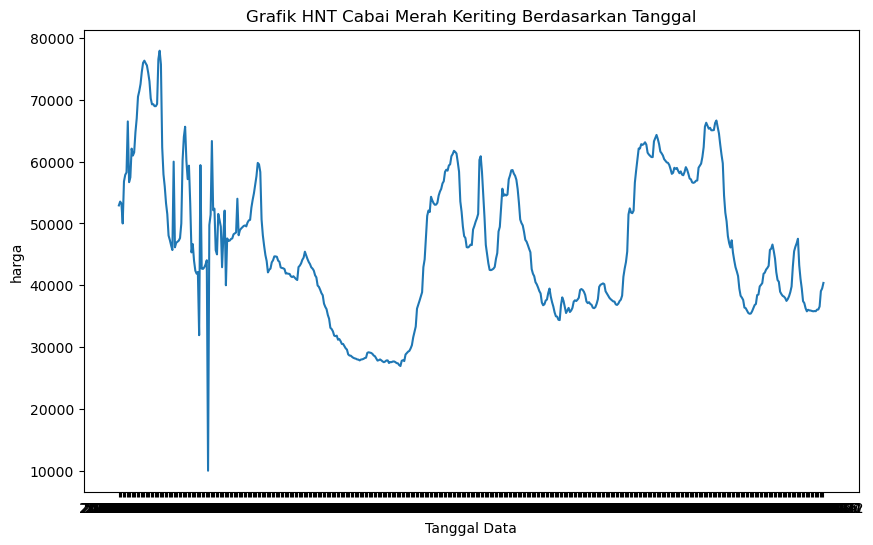

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(df['tanggal_data'], df['harga'])
plt.xlabel('Tanggal Data')
plt.ylabel('harga')
plt.title('Grafik HNT Cabai Merah Keriting Berdasarkan Tanggal')

In [34]:
df.describe()

,harga
count,554.000000
mean,46310.373646
std,11656.104258
min,10000.000000
25%,37509.750000
50%,44386.500000
75%,56425.000000
max,77943.000000


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554 entries, 0 to 553
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   tanggal_data  554 non-null    object
 1   harga         554 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


# Preprocessing


In [36]:
# ubah tanggal menjadi index
df = df.set_index('tanggal_data')

# sorting data tanggal agar terurut
df = df.sort_index()

# Tangani missing values dengan interpolasi linear
df['harga'] = df['harga'].interpolate(method='linear')

print(df.head())
print(f"Missing Value: {df['harga'].isnull().sum()}")

              harga
tanggal_data       
2024-02-01    52916
2024-02-02    53538
2024-02-03    53222
2024-02-04    50000
2024-02-05    56797
Missing Value: 0


In [37]:
# Gabungkan dataset harga dengan data hari libur
holiday_df = pd.read_json('../../data/processed/hari_libur.json')
holiday_df['tanggal'] = pd.to_datetime(holiday_df['tanggal'])

# Gabungkan deskripsi hari libur yang sama pada tanggal yang sama agar merge tidak menggandakan baris
holiday_df = holiday_df.groupby('tanggal', as_index=False).agg({
    'keterangan': lambda x: ', '.join(x.astype(str)),
    'jenis_libur': lambda x: ', '.join(x.astype(str))
})

# Reset index dari df jika diperlukan, lalu merge berdasarkan tanggal_data
df = df.reset_index()
if 'tanggal_data' not in df.columns:
    raise ValueError('Kolom tanggal_data tidak ditemukan di df.')

# Hapus kolom hari libur lama jika ada agar merge tidak membuat duplikat kolom
df = df.drop(columns=[c for c in ['keterangan', 'jenis_libur', 'is_libur'] if c in df.columns])

# Pastikan tanggal_data bertipe datetime untuk join yang akurat
df['tanggal_data'] = pd.to_datetime(df['tanggal_data'])

holiday_df = holiday_df.rename(columns={'tanggal': 'tanggal_data'})
df = df.merge(holiday_df, on='tanggal_data', how='left')

df = df.set_index('tanggal_data')

# Tambahkan flag libur untuk analisis
df['is_libur'] = df['jenis_libur'].notna()

print(df[['harga', 'is_libur', 'jenis_libur', 'keterangan']].head())
print(f"Jumlah baris dengan hari libur: {df['is_libur'].sum()}")

              harga  is_libur jenis_libur keterangan
tanggal_data                                        
2024-02-01    52916     False         NaN        NaN
2024-02-02    53538     False         NaN        NaN
2024-02-03    53222     False         NaN        NaN
2024-02-04    50000     False         NaN        NaN
2024-02-05    56797     False         NaN        NaN
Jumlah baris dengan hari libur: 27


In [40]:
df.to_csv('data_with_holidays.csv', index=True)

In [38]:
df

,harga,keterangan,jenis_libur,is_libur
tanggal_data,,,,
2024-02-01,52916,NaN,NaN,False
2024-02-02,53538,NaN,NaN,False
2024-02-03,53222,NaN,NaN,False
2024-02-04,50000,NaN,NaN,False
2024-02-05,56797,NaN,NaN,False
...,...,...,...,...
2026-04-16,36083,NaN,NaN,False
2026-04-17,36567,NaN,NaN,False
2026-04-20,39054,NaN,NaN,False


# Rolling Mean dan Std

Rolling Mean: memperhalus data (mengurangi fluktuasi jangka pendek)

Rolling Std: mengukur volatilitas dan risiko (kestabilan data)


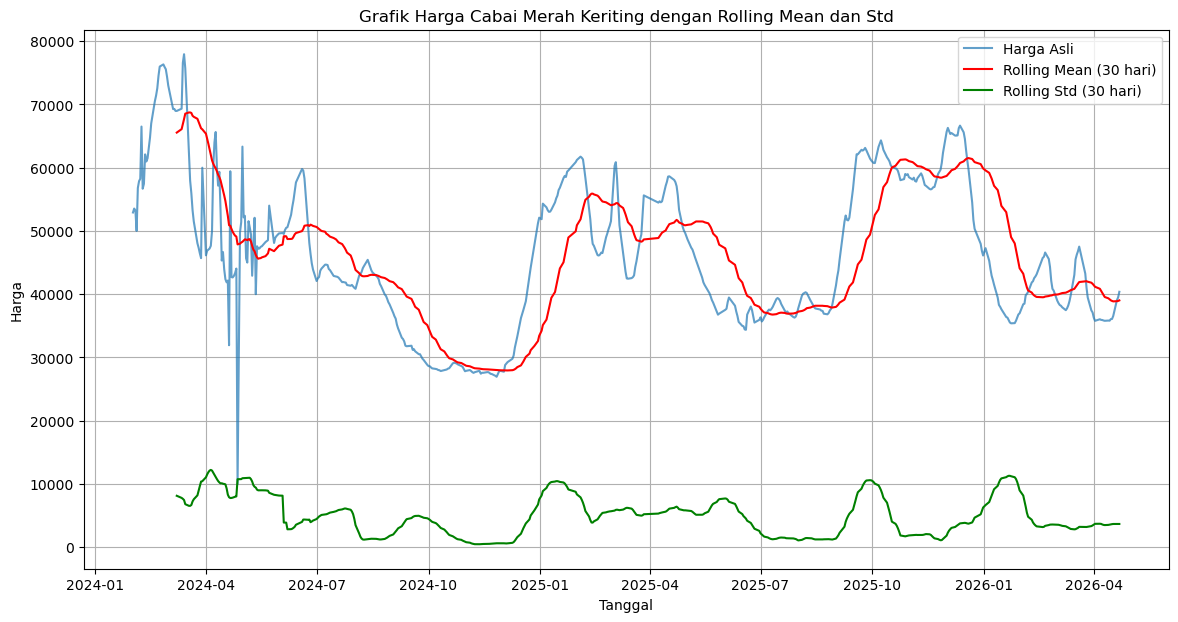

In [39]:

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['harga'], label='Harga Asli', alpha=0.7)

# Hitung rolling mean dan rolling std dengan window 30 hari
rolling_mean = df['harga'].rolling(window=30).mean()
rolling_std = df['harga'].rolling(window=30).std()

plt.plot(rolling_mean.index, rolling_mean, label='Rolling Mean (30 hari)', color='red')
plt.plot(rolling_std.index, rolling_std, label='Rolling Std (30 hari)', color='green')

plt.title('Grafik Harga Cabai Merah Keriting dengan Rolling Mean dan Std')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()

# Dekomposisi Time Series

Mengubah data menjadi Trend, Seasonal, dan Residual

di kasus ini, saya mengasumsikan ada pola bulanan


<Figure size 1200x800 with 0 Axes>

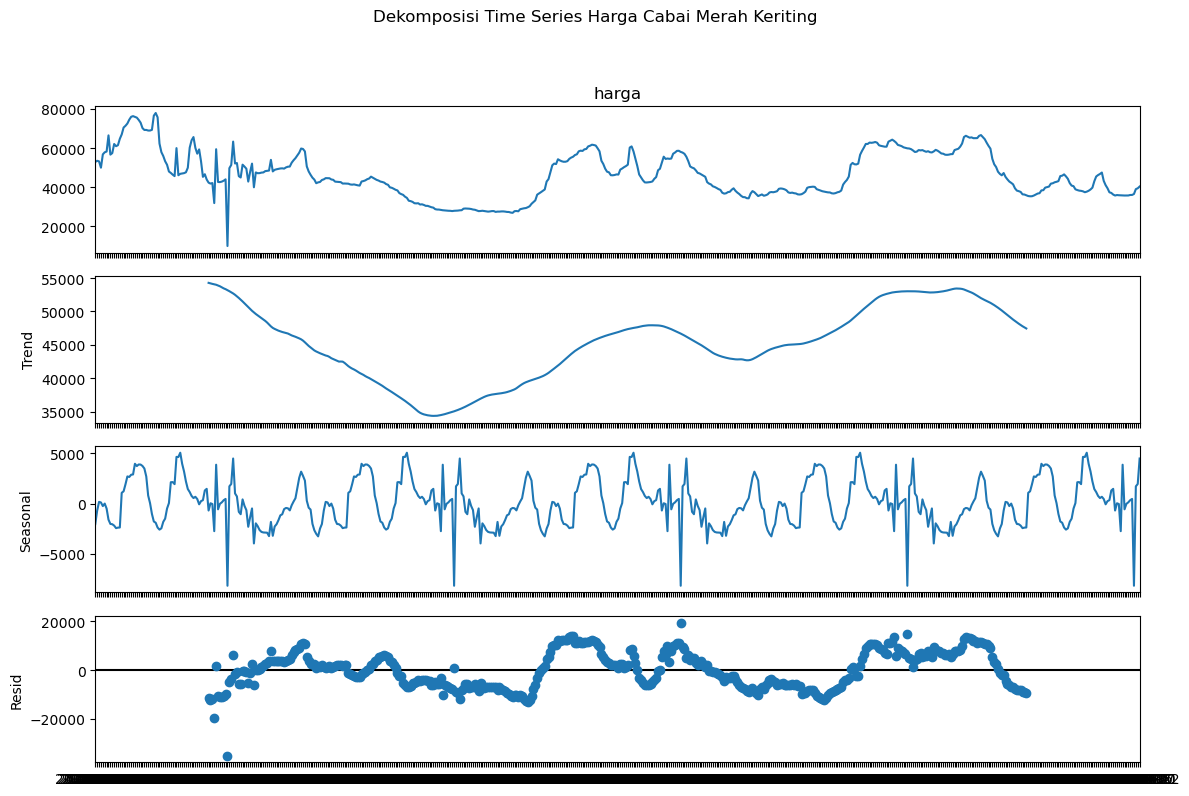

In [11]:
# Dekomposisi aditif
decomposition = seasonal_decompose(df['harga'], model='additive', period=120)

plt.figure(figsize=(12, 8))
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Dekomposisi Time Series Harga Cabai Merah Keriting', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [12]:
# --- 4. Uji Stasioneritas (Augmented Dickey-Fuller Test) ---
print("\n--- Uji Stasioneritas (ADF Test) ---")
# Hapus NaN jika ada, yang mungkin muncul dari rolling atau interpolasi awal
df_clean = df['harga'].dropna()

if not df_clean.empty:
    result = adfuller(df_clean)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if result[1] <= 0.05:
        print("Kesimpulan: Data kemungkinan stasioner (Tolak H0).")
    else:
        print("Kesimpulan: Data kemungkinan tidak stasioner (Gagal tolak H0).")
else:
    print("Tidak ada data yang cukup untuk melakukan uji ADF.")


--- Uji Stasioneritas (ADF Test) ---
ADF Statistic: -2.965812
p-value: 0.038213
Critical Values:
	1%: -3.442
	5%: -2.867
	10%: -2.570
Kesimpulan: Data kemungkinan stasioner (Tolak H0).



--- Grafik ACF dan PACF ---


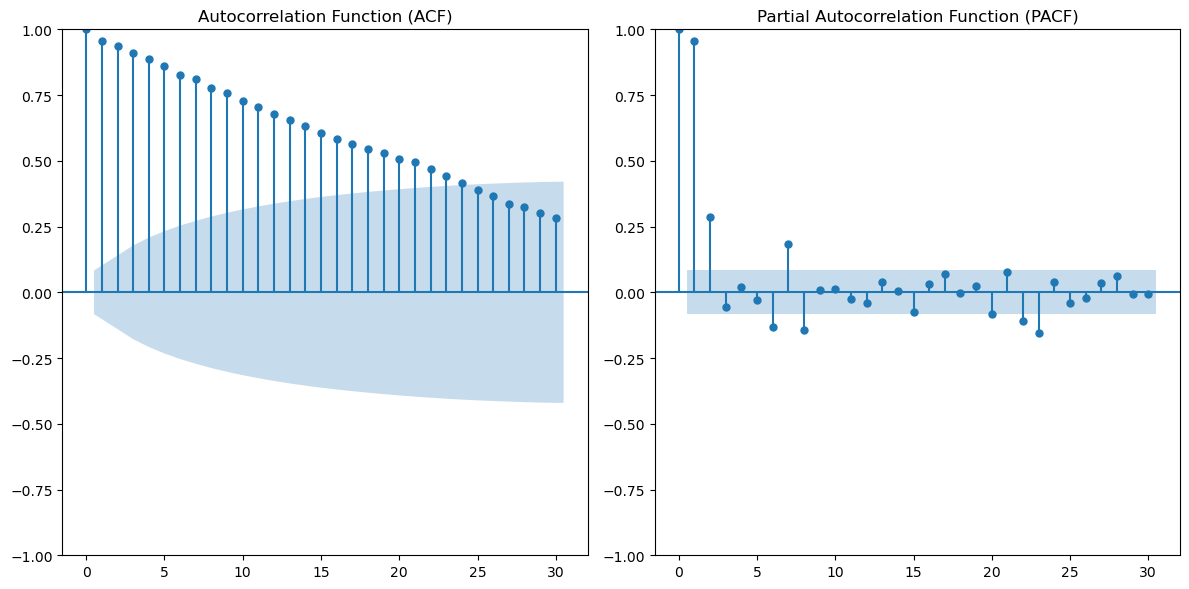

In [13]:
# --- 5. Korelasi (ACF dan PACF Plots) ---
print("\n--- Grafik ACF dan PACF ---")
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df['harga'].dropna(), lags=30, ax=plt.gca(), title='Autocorrelation Function (ACF)')
plt.subplot(122)
plot_pacf(df['harga'].dropna(), lags=30, ax=plt.gca(), title='Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()


--- Analisis Musiman (Boxplot Harga per Bulan) ---


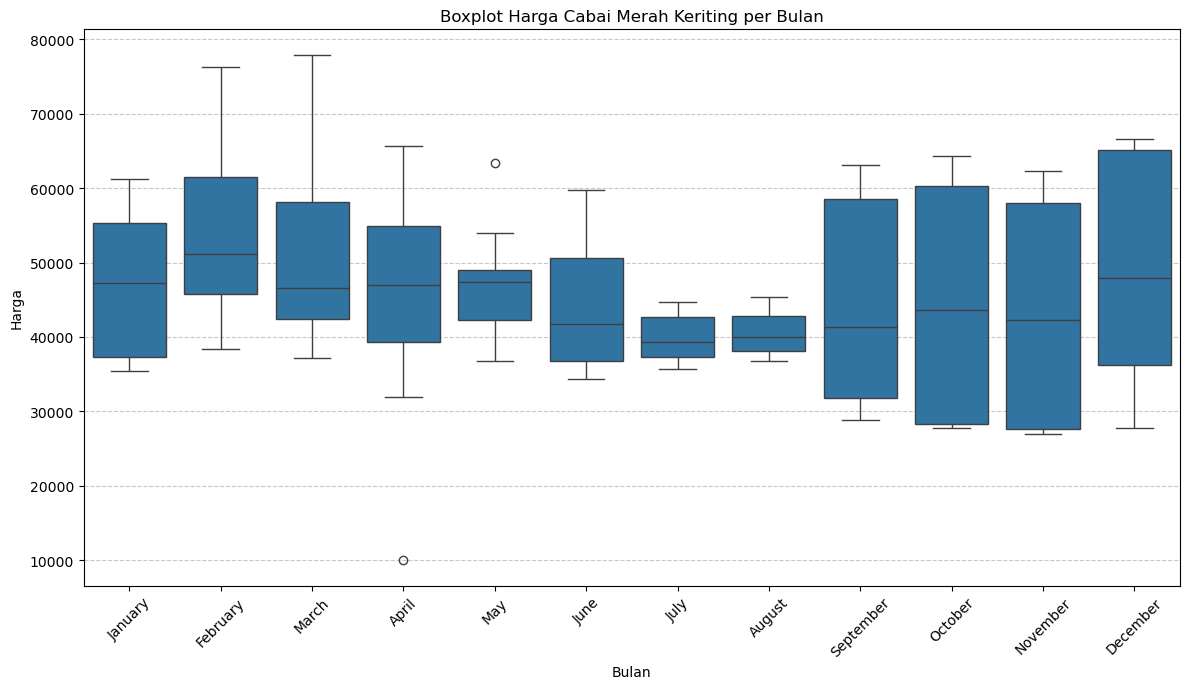


--- EDA Mendalam Selesai ---


In [18]:
# --- 6. Analisis Musiman (Boxplot per Bulan) ---
print("\n--- Analisis Musiman (Boxplot Harga per Bulan) ---")
# Buat kolom bulan dari index tanggal
df['month'] = pd.to_datetime(df.index).strftime('%B')

plt.figure(figsize=(12, 7))
sns.boxplot(x='month', y='harga', data=df, order=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
plt.title('Boxplot Harga Cabai Merah Keriting per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Hapus kolom 'month' jika tidak lagi diperlukan
df = df.drop(columns=['month'])

print("\n--- EDA Mendalam Selesai ---")